# RAPC Lab

Notebook exploratoire pour les prototypes RAPC.

Idée directrice : le ML/GPU est utilisé comme microscope de recherche, pas comme loi physique. Le modèle final doit rester une règle explicite du type :

```text
géométrie = compression spectrale stable des corrélations modulaires
```


In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from pathlib import Path
import sys
import csv
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if (ROOT / "source").exists():
    sys.path.insert(0, str(ROOT / "source"))
print(ROOT)

try:
    import torch
    print('torch:', torch.__version__)
    print('cuda:', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('device:', torch.cuda.get_device_name(0))
except Exception as exc:
    print('torch unavailable:', repr(exc))


C:\DEV\Workspace\active\coding\new_cadre
torch unavailable: OSError(22, 'La procédure spécifiée est introuvable.', None, 127)


## Charger les scans existants

On compare les variantes :

- MDL simple : `rapc_phase_scan_results.csv`
- MDL + localité spectrale : `rapc_spectral_locality_scan_results.csv`
- patch gluing : `rapc_patch_gluing_scan_results.csv`
- patch gluing avec mémoire résiduelle : `rapc_residual_patch_gluing_scan_results.csv`


In [2]:
def load_csv(path):
    path = ROOT / path
    if not path.exists():
        print('missing:', path.name)
        return []
    with path.open(newline='', encoding='utf-8') as handle:
        rows = list(csv.DictReader(handle))
    for row in rows:
        row['lambda'] = float(row['lambda'])
        for key in ['final_edges', 'final_components', 'final_largest']:
            if key in row and row[key] != '':
                row[key] = int(row[key])
        for key in ['final_info', 'final_score', 'final_gap', 'final_degree_variance']:
            if key in row and row[key] != '':
                row[key] = float(row[key])
    return rows

datasets = {
    'mdl_simple': load_csv('rapc_phase_scan_results.csv'),
    'spectral': load_csv('rapc_spectral_locality_scan_results.csv'),
    'patch': load_csv('rapc_patch_gluing_scan_results.csv'),
    'residual_patch': load_csv('rapc_residual_patch_gluing_scan_results.csv'),
}
{name: len(rows) for name, rows in datasets.items()}


{'mdl_simple': 180, 'spectral': 160, 'patch': 160, 'residual_patch': 160}

In [3]:
def phase_key(row):
    return row.get('phase') or row.get('post_phase') or row.get('pre_final_phase')

def summarize(rows):
    by_lambda = defaultdict(list)
    for row in rows:
        by_lambda[row['lambda']].append(row)
    summary = []
    for lam in sorted(by_lambda):
        subset = by_lambda[lam]
        counts = Counter(phase_key(row) for row in subset)
        summary.append({
            'lambda': lam,
            'total': len(subset),
            'empty': counts['empty'],
            'fragmented_sparse': counts['fragmented_sparse'],
            'sparse_geometric': counts['sparse_geometric'],
            'dense_nonlocal': counts['dense_nonlocal'],
            'mean_edges': np.mean([row['final_edges'] for row in subset]),
        })
    return summary

for name, rows in datasets.items():
    print('\n', name)
    for item in summarize(rows):
        print(item)



 mdl_simple
{'lambda': 0.02, 'total': 20, 'empty': 0, 'fragmented_sparse': 11, 'sparse_geometric': 6, 'dense_nonlocal': 3, 'mean_edges': np.float64(5.1)}
{'lambda': 0.04, 'total': 20, 'empty': 2, 'fragmented_sparse': 14, 'sparse_geometric': 3, 'dense_nonlocal': 1, 'mean_edges': np.float64(3.55)}
{'lambda': 0.06, 'total': 20, 'empty': 3, 'fragmented_sparse': 14, 'sparse_geometric': 2, 'dense_nonlocal': 1, 'mean_edges': np.float64(2.5)}
{'lambda': 0.08, 'total': 20, 'empty': 7, 'fragmented_sparse': 12, 'sparse_geometric': 1, 'dense_nonlocal': 0, 'mean_edges': np.float64(1.45)}
{'lambda': 0.1, 'total': 20, 'empty': 10, 'fragmented_sparse': 10, 'sparse_geometric': 0, 'dense_nonlocal': 0, 'mean_edges': np.float64(0.8)}
{'lambda': 0.12, 'total': 20, 'empty': 13, 'fragmented_sparse': 7, 'sparse_geometric': 0, 'dense_nonlocal': 0, 'mean_edges': np.float64(0.4)}
{'lambda': 0.16, 'total': 20, 'empty': 18, 'fragmented_sparse': 2, 'sparse_geometric': 0, 'dense_nonlocal': 0, 'mean_edges': np.float

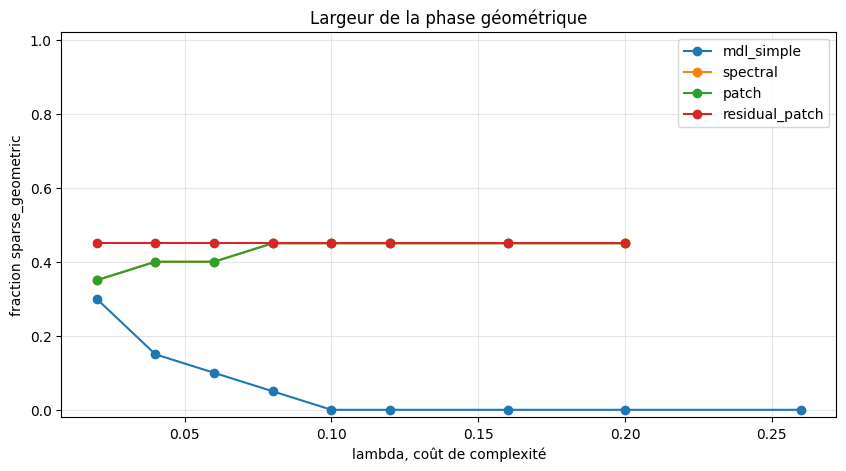

In [4]:
def plot_geo_fraction(datasets):
    plt.figure(figsize=(10, 5))
    for name, rows in datasets.items():
        if not rows:
            continue
        summary = summarize(rows)
        xs = [item['lambda'] for item in summary]
        ys = [item['sparse_geometric'] / item['total'] for item in summary]
        plt.plot(xs, ys, marker='o', label=name)
    plt.xlabel('lambda, coût de complexité')
    plt.ylabel('fraction sparse_geometric')
    plt.title('Largeur de la phase géométrique')
    plt.ylim(-0.02, 1.02)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_geo_fraction(datasets)


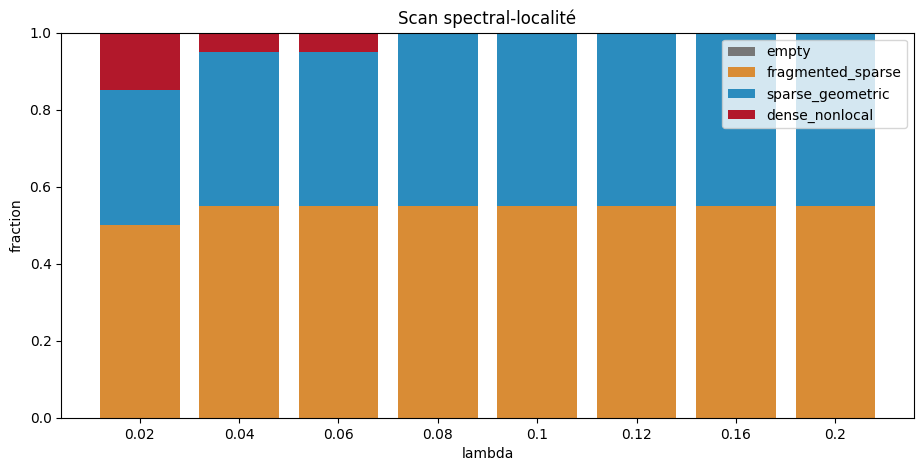

In [5]:
def plot_phase_stack(rows, title):
    summary = summarize(rows)
    phases = ['empty', 'fragmented_sparse', 'sparse_geometric', 'dense_nonlocal']
    colors = {
        'empty': '#777777',
        'fragmented_sparse': '#d98c35',
        'sparse_geometric': '#2b8cbe',
        'dense_nonlocal': '#b2182b',
    }
    xs = np.arange(len(summary))
    bottom = np.zeros(len(summary))
    plt.figure(figsize=(11, 5))
    for phase in phases:
        vals = np.array([item[phase] / item['total'] for item in summary])
        plt.bar(xs, vals, bottom=bottom, label=phase, color=colors[phase])
        bottom += vals
    plt.xticks(xs, [str(item['lambda']) for item in summary])
    plt.xlabel('lambda')
    plt.ylabel('fraction')
    plt.title(title)
    plt.legend(loc='upper right')
    plt.show()

plot_phase_stack(datasets['spectral'], 'Scan spectral-localité')


## Relancer un scan depuis le notebook

Cette cellule est volontairement petite. Pour un gros scan, augmenter `seeds_per_lambda`.


In [6]:
from rapc_spectral_locality_scan_toy import SpectralParams, run_scan, summarize as summarize_spectral

params = SpectralParams(
    n=6,
    seeds_per_lambda=5,
    lambdas=(0.04, 0.08, 0.12),
    steps=6,
)
rows = run_scan(params)
print(summarize_spectral(rows, params.lambdas))


lambda=0.04 empty=00/5 frag=04/5 geo=01/5 dense=00/5 stable_geo=01/5 mean_edges=5.00 mean_gap=0.000 mean_info=0.416
lambda=0.08 empty=00/5 frag=04/5 geo=01/5 dense=00/5 stable_geo=01/5 mean_edges=4.60 mean_gap=0.000 mean_info=0.373
lambda=0.12 empty=00/5 frag=04/5 geo=01/5 dense=00/5 stable_geo=01/5 mean_edges=4.20 mean_gap=0.000 mean_info=0.297


## Zone ML/GPU : microscope, pas loi physique

La RTX peut servir à accélérer une recherche de paramètres ou entraîner un classifieur qui prédit quelles graines donnent une phase géométrique. Mais si une régularité est trouvée, on doit la distiller en règle explicite. Le réseau neuronal ne doit pas devenir l'ontologie du modèle.


In [7]:
try:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    x = torch.randn(4096, 4096, device=device)
    y = x @ x.T
    print(device, y.shape, float(y[0, 0].detach().cpu()))
except Exception as exc:
    print('GPU smoke test failed:', repr(exc))


GPU smoke test failed: NameError("name 'torch' is not defined")
